<a href="https://colab.research.google.com/github/Deepikadandolu/Tsetlin_Machines_Projects/blob/main/sms_class_comp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy==1.26.4
!pip install tmu==0.8.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 39.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 kB 38.8 MB/s eta 0:00:00


KeyboardInterrupt: 

In [1]:
# Install Required Packages

!pip install -q pyTsetlinMachine
!pip install -q kagglehub
!pip install -q wordcloud
!pip install -q openpyxl

In [2]:
import numpy as np
import pandas as pd

print(np.__version__)
print(pd.__version__)


1.26.4
2.2.2


In [3]:
import sys
print(sys.version)
import tmu
print(tmu.__version__)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
0.8.3


In [4]:
from tmu.models.classification.vanilla_classifier import TMClassifier

tm = TMClassifier(
    number_of_clauses=100,
    T=50,
    s=5.0
)

print("TM Created")

ERROR:tmu.clause_bank.clause_bank_cuda:No module named 'pycuda'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tmu/clause_bank/clause_bank_cuda.py", line 41, in <module>
    from pycuda._driver import Device, Context
ModuleNotFoundError: No module named 'pycuda'


TM Created


In [5]:
import numpy as np

X = np.array([
    [1,0,1],
    [0,1,0],
    [1,1,0],
    [0,0,1]
], dtype=np.uint32)

Y = np.array([0,1,1,0], dtype=np.uint32)

tm.fit(X, Y)

{}

In [6]:
# Standard Libraries
import os
import re
import time
import pickle
import warnings
import collections

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Dataset Download
import kagglehub

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Embedding,
    LSTM,
    Dropout,
    Bidirectional
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tsetlin Machine
from tmu.models.classification.vanilla_classifier import TMClassifier

# Model Saving
import joblib

# Settings
warnings.filterwarnings("ignore")

pd.options.display.float_format = '{:.3f}'.format

seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# NLTK Downloads
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [7]:
# =========================
# HELPER FUNCTIONS
# =========================

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', str(text))
    text = text.lower()
    text = text.split()

    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))

    text = [
        lemmatizer.lemmatize(word)
        for word in text
        if word not in stop_words
    ]

    return ' '.join(text)


def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }


def get_model_size(filepath):
    return os.path.getsize(filepath) / (1024 * 1024)  # MB


def plot_confusion_matrix(cm, classes):

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


def plot_history(history):

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title("Loss")
    plt.legend(['Train', 'Validation'])

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title("Accuracy")
    plt.legend(['Train', 'Validation'])

    plt.show()


# Results Storage

results = []

In [8]:
# Download Dataset from Kaggle

path = kagglehub.dataset_download(
    "hamnawaseem112222222/sms-spam-collection-5572-labeled-sms-messages"
)

print("Dataset Path:", path)

Using Colab cache for faster access to the 'sms-spam-collection-5572-labeled-sms-messages' dataset.
Dataset Path: /kaggle/input/sms-spam-collection-5572-labeled-sms-messages


In [9]:
# Load Dataset

import os

print(os.listdir(path))

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]

df = pd.read_csv(os.path.join(path, csv_file))

df.head()

['sms_spam_collection (1).csv']


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# Dataset Inspection

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nClass Distribution:")
print(df.iloc[:, 0].value_counts())

df.head()

Shape: (5572, 2)

Columns:
Index(['label', 'message'], dtype='object')

Data Types:
label      object
message    object
dtype: object

Missing Values:
label      0
message    0
dtype: int64

Duplicate Rows: 403

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
# Data Cleaning & Preprocessing

# Rename Columns (adjust if necessary)
df.columns = ['label', 'message']

# Remove Duplicates
df = df.drop_duplicates()

# Encode Labels
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

# Clean Messages
df['clean_message'] = df['message'].apply(clean_text)

# Features and Labels
X = df['clean_message']
y = df['label']

print("Dataset Shape:", df.shape)
df[['message', 'clean_message', 'label']].head()

Dataset Shape: (5169, 3)


,message,clean_message,label
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...,0
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...,1
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say,0
4,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though,0


In [12]:
# Train-Test Split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=seed,
    stratify=y
)

print("Training Samples :", len(X_train_text))
print("Testing Samples  :", len(X_test_text))

Training Samples : 4135
Testing Samples  : 1034


In [15]:
# CountVectorizer

cv = CountVectorizer(
    max_features=5000
)

X_train_cv = cv.fit_transform(X_train_text).toarray()
X_test_cv = cv.transform(X_test_text).toarray()

print("X_train shape:", X_train_cv.shape)
print("X_test shape :", X_test_cv.shape)

X_train shape: (4135, 5000)
X_test shape : (1034, 5000)


In [13]:
# Benchmark Helper Functions

def benchmark_model(model_name,
                    y_true,
                    y_pred,
                    train_time,
                    inference_time,
                    model_size):

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "Training_Time(s)": train_time,
        "Inference_Time(s)": inference_time,
        "Model_Size(MB)": model_size
    })


def measure_inference_time(model, X):

    start = time.time()
    _ = model.predict(X)
    end = time.time()

    return end - start


def save_model_size(filepath):

    return round(os.path.getsize(filepath) / (1024 * 1024), 4)


def print_metrics(y_true, y_pred):

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred))

Accuracy : 0.8588007736943907
Precision: 0.4691358024691358
Recall   : 0.8702290076335878
F1 Score : 0.6096256684491979

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.86      0.91       903
           1       0.47      0.87      0.61       131

    accuracy                           0.86      1034
   macro avg       0.72      0.86      0.76      1034
weighted avg       0.91      0.86      0.88      1034



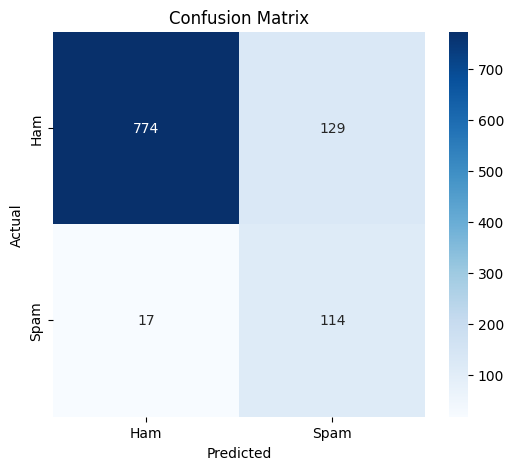

In [16]:
# Gaussian Naive Bayes

gnb = GaussianNB()

start_time = time.time()

gnb.fit(X_train_cv, y_train)

train_time = time.time() - start_time

start_time = time.time()

y_pred_gnb = gnb.predict(X_test_cv)

inference_time = time.time() - start_time

print_metrics(y_test, y_pred_gnb)

cm = confusion_matrix(y_test, y_pred_gnb)
plot_confusion_matrix(cm, ["Ham", "Spam"])

In [17]:
# Save GaussianNB

joblib.dump(gnb, "gaussian_nb.pkl")

gnb_size = save_model_size("gaussian_nb.pkl")

benchmark_model(
    model_name="GaussianNB",
    y_true=y_test,
    y_pred=y_pred_gnb,
    train_time=train_time,
    inference_time=inference_time,
    model_size=gnb_size
)

print(f"Model Size: {gnb_size:.4f} MB")

Model Size: 0.1533 MB


Accuracy : 0.9806576402321083
Precision: 0.9172932330827067
Recall   : 0.9312977099236641
F1 Score : 0.9242424242424242

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       903
           1       0.92      0.93      0.92       131

    accuracy                           0.98      1034
   macro avg       0.95      0.96      0.96      1034
weighted avg       0.98      0.98      0.98      1034



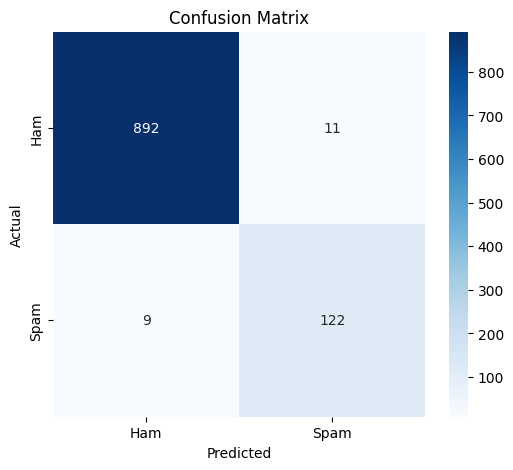

In [18]:
# Multinomial Naive Bayes

mnb = MultinomialNB()

start_time = time.time()

mnb.fit(X_train_cv, y_train)

train_time = time.time() - start_time

start_time = time.time()

y_pred_mnb = mnb.predict(X_test_cv)

inference_time = time.time() - start_time

print_metrics(y_test, y_pred_mnb)

cm = confusion_matrix(y_test, y_pred_mnb)
plot_confusion_matrix(cm, ["Ham", "Spam"])

In [19]:
# Save MultinomialNB

joblib.dump(mnb, "multinomial_nb.pkl")

mnb_size = save_model_size("multinomial_nb.pkl")

benchmark_model(
    model_name="MultinomialNB",
    y_true=y_test,
    y_pred=y_pred_mnb,
    train_time=train_time,
    inference_time=inference_time,
    model_size=mnb_size
)

print(f"Model Size: {mnb_size:.4f} MB")

Model Size: 0.1533 MB


Accuracy : 0.97678916827853
Precision: 0.9908256880733946
Recall   : 0.8244274809160306
F1 Score : 0.9

Classification Report

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.99      0.82      0.90       131

    accuracy                           0.98      1034
   macro avg       0.98      0.91      0.94      1034
weighted avg       0.98      0.98      0.98      1034



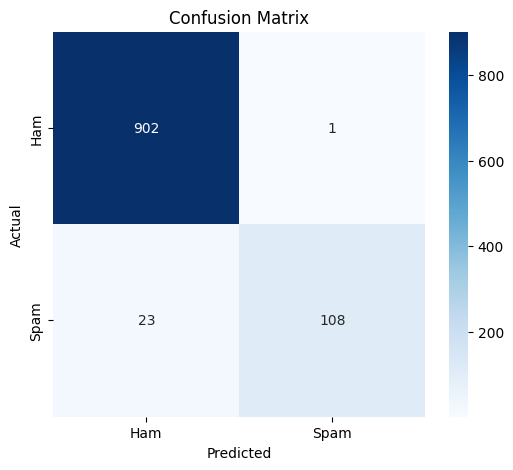

In [20]:
# Logistic Regression

lr = LogisticRegression(
    max_iter=1000,
    random_state=seed
)

start_time = time.time()

lr.fit(X_train_cv, y_train)

train_time = time.time() - start_time

start_time = time.time()

y_pred_lr = lr.predict(X_test_cv)

inference_time = time.time() - start_time

print_metrics(y_test, y_pred_lr)

cm = confusion_matrix(y_test, y_pred_lr)
plot_confusion_matrix(cm, ["Ham", "Spam"])

In [21]:
# Save Logistic Regression

joblib.dump(lr, "logistic_regression.pkl")

lr_size = save_model_size("logistic_regression.pkl")

benchmark_model(
    model_name="Logistic Regression",
    y_true=y_test,
    y_pred=y_pred_lr,
    train_time=train_time,
    inference_time=inference_time,
    model_size=lr_size
)

print(f"Model Size: {lr_size:.4f} MB")

Model Size: 0.0390 MB


Epoch 01 | Train Acc: 0.8863 | Test Acc: 0.9033
Epoch 02 | Train Acc: 0.8912 | Test Acc: 0.9130
Epoch 03 | Train Acc: 0.8914 | Test Acc: 0.9101
Epoch 04 | Train Acc: 0.8875 | Test Acc: 0.9217
Epoch 05 | Train Acc: 0.8883 | Test Acc: 0.9217
Epoch 06 | Train Acc: 0.8890 | Test Acc: 0.9101
Epoch 07 | Train Acc: 0.8813 | Test Acc: 0.9062
Epoch 08 | Train Acc: 0.8859 | Test Acc: 0.9072
Epoch 09 | Train Acc: 0.8900 | Test Acc: 0.9188
Epoch 10 | Train Acc: 0.8846 | Test Acc: 0.9188
Epoch 11 | Train Acc: 0.8839 | Test Acc: 0.9168
Epoch 12 | Train Acc: 0.8931 | Test Acc: 0.9178
Epoch 13 | Train Acc: 0.8902 | Test Acc: 0.9178
Epoch 14 | Train Acc: 0.8856 | Test Acc: 0.9130
Epoch 15 | Train Acc: 0.8880 | Test Acc: 0.9139
Epoch 16 | Train Acc: 0.8851 | Test Acc: 0.9168
Epoch 17 | Train Acc: 0.8834 | Test Acc: 0.9101
Epoch 18 | Train Acc: 0.8875 | Test Acc: 0.9159
Epoch 19 | Train Acc: 0.8885 | Test Acc: 0.9023
Epoch 20 | Train Acc: 0.8904 | Test Acc: 0.9110
Epoch 21 | Train Acc: 0.8921 | Test Acc:

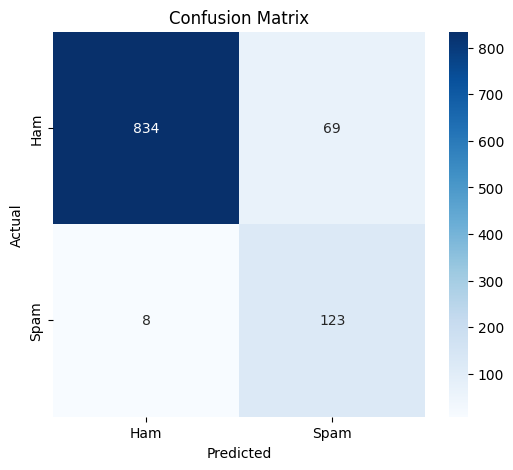

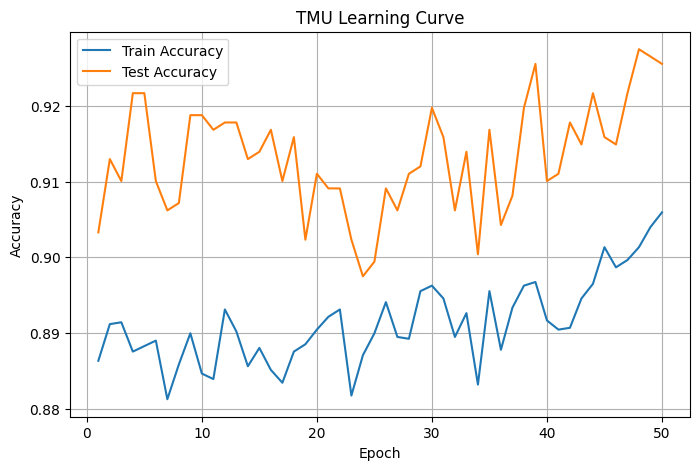


Best Test Accuracy: 0.9275
Final Test Accuracy: 0.9255


In [22]:
# TMU + Epoch-wise Learning Curve + Final Evaluation

# Convert CountVectorizer features to binary features
X_train_tm = (X_train_cv > 0).astype(np.uint32)
X_test_tm = (X_test_cv > 0).astype(np.uint32)

y_train_tm = y_train.to_numpy(dtype=np.uint32)
y_test_tm = y_test.to_numpy(dtype=np.uint32)

epochs = 50

train_acc_history = []
test_acc_history = []

tm = TMClassifier(
    number_of_clauses=2000,
    T=1000,
    s=10.0,
    platform="CPU"
)

start_time = time.time()

for epoch in range(epochs):

    tm.fit(X_train_tm, y_train_tm)

    train_pred = tm.predict(X_train_tm)
    test_pred = tm.predict(X_test_tm)

    train_acc = accuracy_score(y_train_tm, train_pred)
    test_acc = accuracy_score(y_test_tm, test_pred)

    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

train_time = time.time() - start_time

# Final Evaluation
start_time = time.time()

y_pred_tm = tm.predict(X_test_tm)

inference_time = time.time() - start_time

print("\nFinal Results")
print_metrics(y_test_tm, y_pred_tm)

cm = confusion_matrix(y_test_tm, y_pred_tm)
plot_confusion_matrix(cm, ["Ham", "Spam"])

# Learning Curve
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_acc_history,
    label="Train Accuracy"
)

plt.plot(
    range(1, epochs + 1),
    test_acc_history,
    label="Test Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("TMU Learning Curve")
plt.legend()
plt.grid(True)

plt.show()

print(f"\nBest Test Accuracy: {max(test_acc_history):.4f}")
print(f"Final Test Accuracy: {test_acc_history[-1]:.4f}")

In [23]:
# Save TMU

joblib.dump(tm, "tmu_model.pkl")

tmu_size = save_model_size("tmu_model.pkl")

benchmark_model(
    model_name="TMU",
    y_true=y_test,
    y_pred=y_pred_tm,
    train_time=train_time,
    inference_time=inference_time,
    model_size=tmu_size
)

print(f"Model Size: {tmu_size:.4f} MB")

Model Size: 235.5868 MB


In [24]:

# BiLSTM Data Preparation

MAX_WORDS = 5000
MAX_LEN = 100

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

y_train_dl = np.array(y_train)
y_test_dl = np.array(y_test)

print("X_train_pad:", X_train_pad.shape)
print("X_test_pad :", X_test_pad.shape)



X_train_pad: (4135, 100)
X_test_pad : (1034, 100)


In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dropout, Dense

bilstm = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),

    Bidirectional(
        LSTM(64, return_sequences=False)
    ),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

bilstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

bilstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 742,977 (2.83 MB)

 Trainable params: 742,977 (2.83 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
bilstm.build((None, MAX_LEN))
bilstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,228,933 (8.50 MB)

 Trainable params: 742,977 (2.83 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,485,956 (5.67 MB)

In [39]:
# BiLSTM Training

start_time = time.time()

history = bilstm.fit(
    X_train_pad,
    y_train_dl,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

train_time = time.time() - start_time

print(f"Training Time: {train_time:.2f} seconds")

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 1.0000 - loss: 5.4874e-04 - val_accuracy: 0.9843 - val_loss: 0.1302
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 2.8135e-04 - val_accuracy: 0.9855 - val_loss: 0.1213
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 5.9907e-05 - val_accuracy: 0.9855 - val_loss: 0.1161
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 3.2890e-05 - val_accuracy: 0.9855 - val_loss: 0.1207
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 2.7279e-05 - val_accuracy: 0.9855 - val_loss: 0.1225
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 1.0000 - loss: 3.8299e-05 - val_accuracy: 0.9855 - val_loss: 0.1262
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 1.0000 - loss: 5.3001e-05 - val_accuracy: 0.9879 - val_loss: 0.1191
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.00

In [40]:
# Save BiLSTM + Tokenizer

bilstm.save("bilstm.keras")

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

bilstm_size = save_model_size("bilstm.keras")

print(f"BiLSTM Model Size: {bilstm_size:.4f} MB")

BiLSTM Model Size: 8.5465 MB


Accuracy : 0.9787234042553191
Precision: 0.957983193277311
Recall   : 0.8702290076335878
F1 Score : 0.912

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       903
           1       0.96      0.87      0.91       131

    accuracy                           0.98      1034
   macro avg       0.97      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



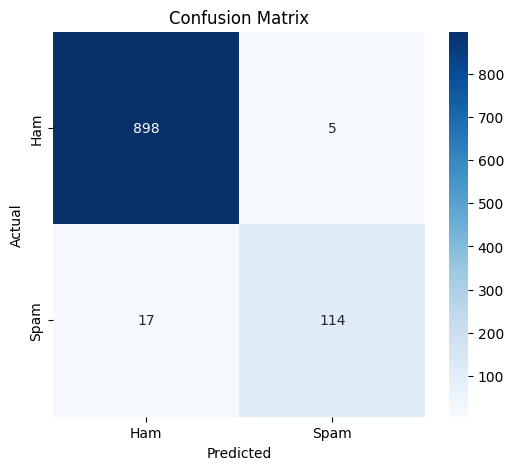

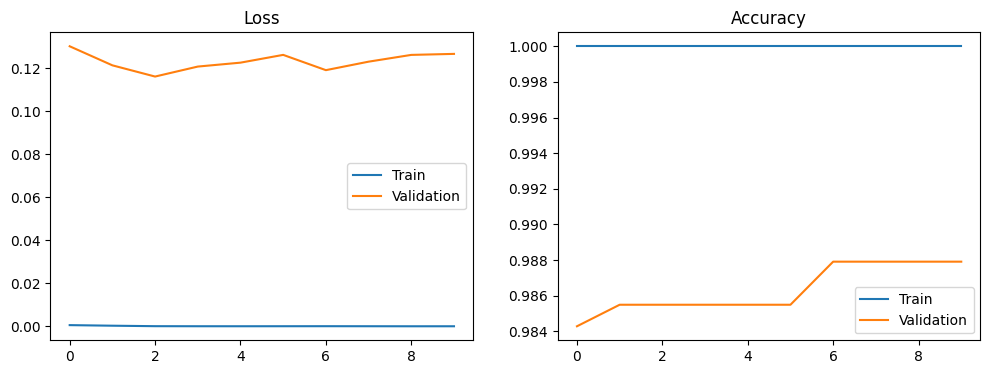

In [41]:
# BiLSTM Evaluation

start_time = time.time()

y_pred_prob = bilstm.predict(X_test_pad, verbose=0)

inference_time = time.time() - start_time

y_pred_bilstm = (y_pred_prob > 0.5).astype(int).flatten()

print_metrics(y_test_dl, y_pred_bilstm)

cm = confusion_matrix(y_test_dl, y_pred_bilstm)
plot_confusion_matrix(cm, ["Ham", "Spam"])

benchmark_model(
    model_name="BiLSTM",
    y_true=y_test_dl,
    y_pred=y_pred_bilstm,
    train_time=train_time,
    inference_time=inference_time,
    model_size=bilstm_size
)

plot_history(history)

In [46]:
bilstm_metrics = results_df[results_df['Model'] == 'BiLSTM'].iloc[0]

print(f"BiLSTM Accuracy: {bilstm_metrics['Accuracy']:.4f}")
print(f"BiLSTM Precision: {bilstm_metrics['Precision']:.4f}")
print(f"BiLSTM Recall: {bilstm_metrics['Recall']:.4f}")
print(f"BiLSTM F1 Score: {bilstm_metrics['F1']:.4f}")

BiLSTM Accuracy: 0.9787
BiLSTM Precision: 0.9580
BiLSTM Recall: 0.8702
BiLSTM F1 Score: 0.9120


In [57]:
# Create Results DataFrame

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df = results_df.drop(
    results_df[
        (results_df["Model"] == "BiLSTM") &
        (results_df["Accuracy"] < 0.95)
    ].index
).reset_index(drop=True)

In [54]:
results_df.style.background_gradient(
    subset=["Accuracy", "Precision", "Recall", "F1"],
    cmap="Greens"
)

,Model,Accuracy,Precision,Recall,F1,Training_Time(s),Inference_Time(s),Model_Size(MB)
0,MultinomialNB,0.980658,0.917293,0.931298,0.924242,0.434714,0.021944,0.153300
1,BiLSTM,0.978723,0.957983,0.870229,0.912000,15.743652,0.658107,8.546500
2,Logistic Regression,0.976789,0.990826,0.824427,0.900000,0.673838,0.019199,0.039000
3,TMU,0.925532,0.640625,0.938931,0.761610,2893.434650,0.145387,235.586800
4,BiLSTM,0.872340,0.000000,0.000000,0.000000,31.155976,1.087233,0.031300
5,GaussianNB,0.858801,0.469136,0.870229,0.609626,0.708591,0.145659,0.153300


In [58]:
# Save Results CSV/XLSX

results_df.to_csv(
    "benchmark_results.csv",
    index=False
)

results_df.to_excel(
    "benchmark_results.xlsx",
    index=False
)

print("Saved: benchmark_results.csv")
print("Saved: benchmark_results.xlsx")

Saved: benchmark_results.csv
Saved: benchmark_results.xlsx


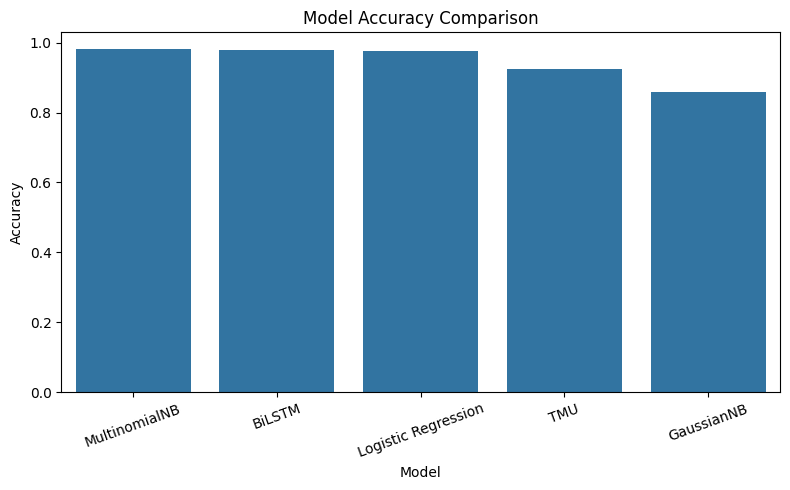

In [59]:
# Accuracy Comparison Plot

plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

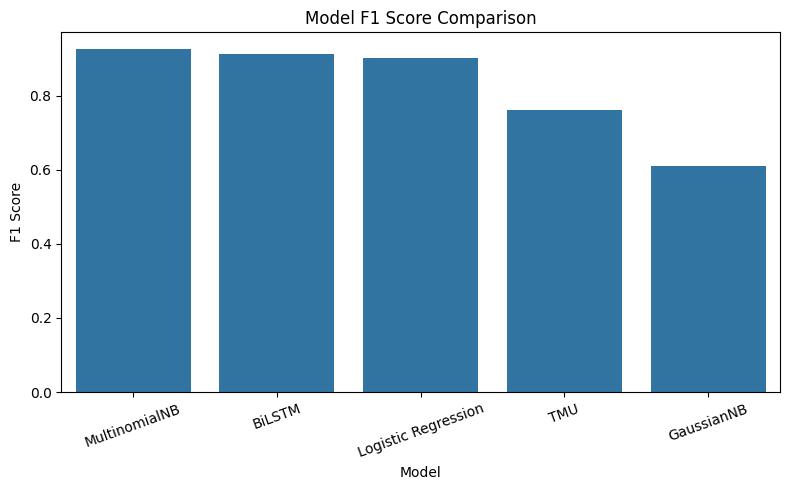

In [60]:
# F1 Comparison Plot

plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1"
)

plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

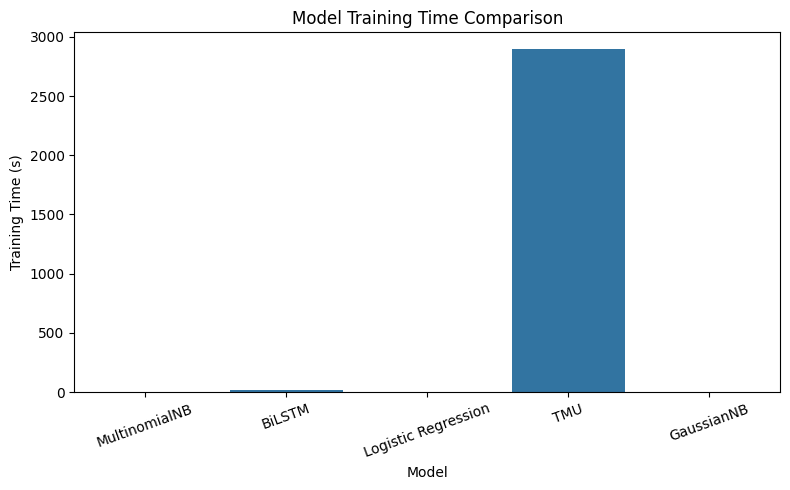

In [61]:
# Training Time Comparison Plot

plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Training_Time(s)"
)

plt.title("Model Training Time Comparison")
plt.ylabel("Training Time (s)")
plt.xlabel("Model")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

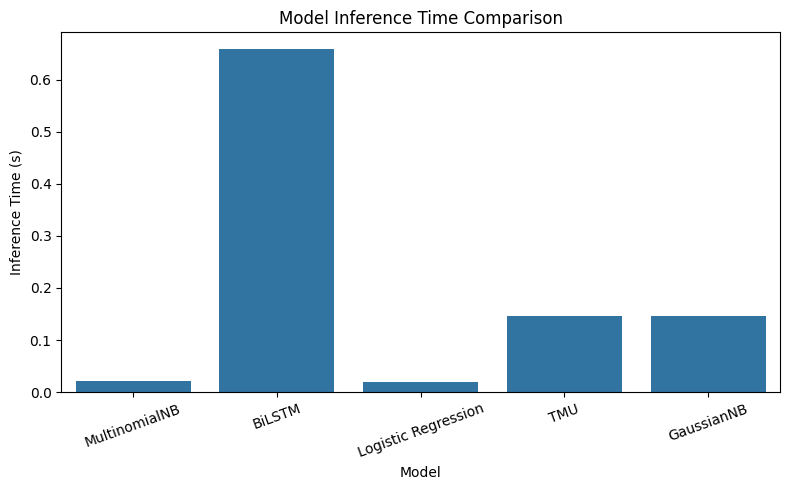

In [62]:
# Inference Time Comparison Plot

plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Inference_Time(s)"
)

plt.title("Model Inference Time Comparison")
plt.ylabel("Inference Time (s)")
plt.xlabel("Model")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

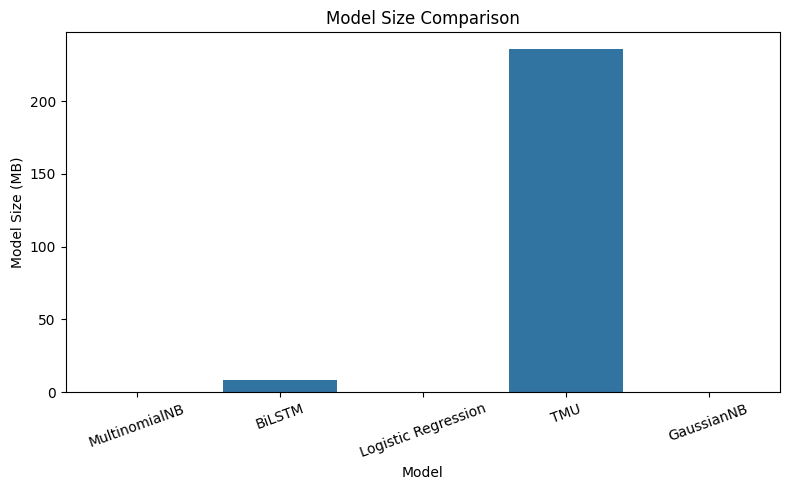

In [63]:
# Model Size Comparison Plot

plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Model_Size(MB)"
)

plt.title("Model Size Comparison")
plt.ylabel("Model Size (MB)")
plt.xlabel("Model")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [64]:
# Final Benchmark Table (Rounded Results)

final_results = results_df.copy()

numeric_cols = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Training_Time(s)",
    "Inference_Time(s)",
    "Model_Size(MB)"
]

final_results[numeric_cols] = final_results[numeric_cols].round(4)

print(final_results)

final_results

final_results.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "Training_Time(s)": "{:.4f}",
    "Inference_Time(s)": "{:.6f}",
    "Model_Size(MB)": "{:.4f}"
})

                 Model  Accuracy  Precision  Recall    F1  Training_Time(s)  \
0        MultinomialNB     0.981      0.917   0.931 0.924             0.435   
1               BiLSTM     0.979      0.958   0.870 0.912            15.744   
2  Logistic Regression     0.977      0.991   0.824 0.900             0.674   
3                  TMU     0.925      0.641   0.939 0.762          2893.435   
4           GaussianNB     0.859      0.469   0.870 0.610             0.709   

   Inference_Time(s)  Model_Size(MB)  
0              0.022           0.153  
1              0.658           8.546  
2              0.019           0.039  
3              0.145         235.587  
4              0.146           0.153  


,Model,Accuracy,Precision,Recall,F1,Training_Time(s),Inference_Time(s),Model_Size(MB)
0,MultinomialNB,0.9807,0.9173,0.9313,0.9242,0.4347,0.021900,0.1533
1,BiLSTM,0.9787,0.9580,0.8702,0.9120,15.7437,0.658100,8.5465
2,Logistic Regression,0.9768,0.9908,0.8244,0.9000,0.6738,0.019200,0.0390
3,TMU,0.9255,0.6406,0.9389,0.7616,2893.4346,0.145400,235.5868
4,GaussianNB,0.8588,0.4691,0.8702,0.6096,0.7086,0.145700,0.1533
